# 3.4 Cluster characterization by means of word clouds and itemset mining
> **In many real cases, the real clustering subdivision is not accessible at all**.  
> **Indeed, it is what you want to discover by clustering your data.**  

For this reason, it is commonplace to **add a further step to the pipeline** and try to characterize the clusters by **inspecting their points’ characteristics**.  
This is especially true while working with news, where the description can lead to the identification of a topic shared among all the documents assigned to it (e.g. one of your clusters may contain news related to sports).

> In this exercise you will exploit word clouds and frequent itemset algorithms to characterize the clusters obtained in the previous exercise.

#### 1. Split your initial data into separate chunks accordingly to the cluster labels obtained in the previous exercise.
For each of them, generate a **Word Cloud image** using the **wordcloud library**. Take a look at the library documentation to learn how to do it.  
> Can you figure out the topic shared among all the news of each cluster?

> # WORDCLOUD, what is it?
- documentation: https://amueller.github.io/word_cloud/index.html

Something like this:

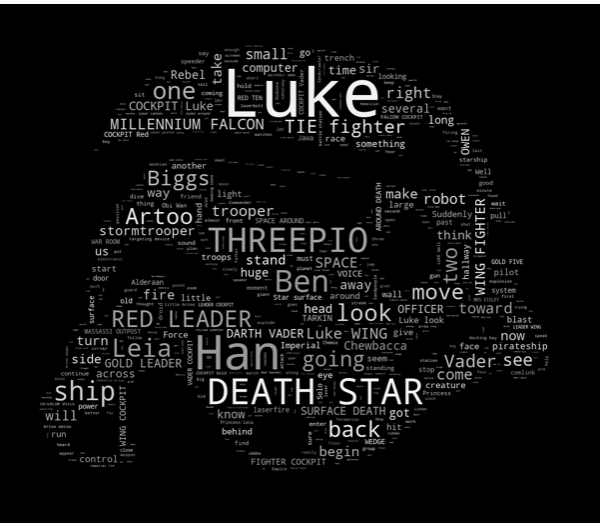

> - **WordCloud([font_path, width, height, …])** : Word cloud object for generating and drawing.
- **ImageColorGenerator(image[, default_color])** : Color generator based on a color image.
- **random_color_func([word, font_size, …])** : Random hue color generation.
- **get_single_color_func(color)** : Create a color function which returns a single hue and saturation with.

> *class wordcloud.WordCloud(font_path=None, width=400, height=200, margin=2, ranks_only=None, prefer_horizontal=0.9, mask=None, scale=1, color_func=None, **max_words=200**, min_font_size=4, **stopwords=None**, **random_state=None**, background_color='black', **max_font_size=None**, font_step=1, mode='RGB', **relative_scaling='auto'**, regexp=None, **collocations=True**, colormap=None, **normalize_plurals=True**, contour_width=0, contour_color='black', repeat=False, **include_numbers=False**, **min_word_length=0**, collocation_threshold=30)[source]*

font_pathstring  
The path (string) to a .ttf / .otf font file that the wordcloud should use. You set it when you want a specific font.  
**COSMETIC**.

widthint (default=400)  
Width of the canvas.  
**COSMETIC**.

heightint (default=200)  
Height of the canvas.  
**COSMETIC**.

prefer_horizontalfloat (default=0.90)  
The ratio of times to try horizontal fitting as opposed to vertical. If prefer_horizontal < 1, the algorithm will try rotating the word if it doesn’t fit. (There is currently no built-in way to get only vertical words.)  
**COSMETIC**.

masknd-array or None (default=None)  
If not None, gives a binary mask on where to draw words. If mask is not None, width and height will be ignored and the shape of mask will be used instead. All white (#FF or #FFFFFF) entries will be considerd “masked out” while other entries will be free to draw on. [This changed in the most recent version!]
**BAH**.

contour_width: float (default=0)  
If mask is not None and contour_width > 0, draw the mask contour.  
**COSMETIC**.

contour_color: color value (default=”black”)  
Mask contour color.  
**COSMETIC**.

scale float (default=1)  
Scaling between computation and drawing. For large word-cloud images, using scale instead of larger canvas size is significantly faster, but might lead to a coarser fit for the words.  
**COSMETIC**.

min_font_size int (default=4)  
Smallest font size to use. Will stop when there is no more room in this size.  
**COSMETIC**.

font_step int (default=1)  
Step size for the font. font_step > 1 might speed up computation but give a worse fit.  
**COSMETIC**.

> **max_words number (default=200)**  
The maximum number of words.  
How many top words to show. Lower = only the most important terms survive.  
**USEFUL**.

> **stopwords set of strings or None**  
The words that will be eliminated. **If None, the build-in STOPWORDS list will be used**. Ignored if using generate_from_frequencies.
**USEFUL**.

background_colorcolor value (default=”black”)  
Background color for the word cloud image.
**COSMETIC**.

> max_font_size int or None (default=None)  
Maximum font size for the largest word. If None, height of the image is used.
**USEFUL**.

mode string (default=”RGB”)  
Transparent background will be generated when mode is “RGBA” and background_color is None.
**COSMETIC**.

> relative_scaling float (default=’auto’)  
Importance of relative word frequencies for font-size. With relative_scaling=0, only word-ranks are considered. With relative_scaling=1, a word that is twice as frequent will have twice the size. If you want to consider the word frequencies and not only their rank, relative_scaling around .5 often looks good. If ‘auto’ it will be set to 0.5 unless repeat is true, in which case it will be set to 0.
**USEFUL**.

color_fun ccallable, default=None  
Callable with parameters word, font_size, position, orientation, font_path, random_state that returns a PIL color for each word. Overwrites “colormap”. See colormap for specifying a matplotlib colormap instead. To create a word cloud with a single color, use color_func=lambda *args, **kwargs: "white". The single color can also be specified using RGB code. For example color_func=lambda *args, **kwargs: (255,0,0) sets color to red.
**COSMETIC**.

regexp string or None (optional)  
Regular expression to split the input text into tokens in process_text. If None is specified, r"\w[\w']+" is used. Ignored if using generate_from_frequencies.
**COSMETIC**.

> **collocations bool, default=True**  
Whether to include collocations (bigrams) of two words. Ignored if using generate_from_frequencies.  
Controls whether it detects bigrams like "new york", "machine learning".
- True: you can see meaningful phrases.
- False: everything split into single words.  
**USEFUL**.

colormap string or matplotlib colormap, default=”viridis”  
Matplotlib colormap to randomly draw colors from for each word. Ignored if “color_func” is specified.
**COSMETIC**.

> normalize_plurals bool, default=True  
Whether to remove trailing ‘s’ from words. If True and a word appears with and without a trailing ‘s’, the one with trailing ‘s’ is removed and its counts are added to the version without trailing ‘s’ – unless the word ends with ‘ss’. Ignored if using generate_from_frequencies.
**USEFUL**.

repeat bool, default=False  
Whether to repeat words and phrases until max_words or min_font_size is reached.
**BAH**.

> include_numbers bool, default=False  
Whether to include numbers as phrases or not.
**USEFUL**.

> min_word_length int, default=0  
Minimum number of letters a word must have to be included.
**USEFUL**.

#### Methods
> fit_words(frequencies)  
Create a word_cloud from words and frequencies.

> generate(text)  
Generate wordcloud from text.

> generate_from_frequencies(frequencies[, …])  
Create a word_cloud from words and frequencies.

> generate_from_text(text)  
Generate wordcloud from text.

> process_text(text)  
Splits a long text into words, eliminates the stopwords.

> recolor([random_state, color_func, colormap])  
Recolor existing layout.

> to_array()  
Convert to numpy array.

> to_file(filename)  
Export to image file.

In [ ]:
# example
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt

text = "cat dog dog mouse dog cat"
wc = WordCloud(width=800, height=400, background_color="white", random_state=41).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

# Let's see again the full pipeline

> I know this pipeline seems small but remember that this is the product of many observations that I did not include, I just pasted the final pipeline, ignoring:  
- data distribution visuaslization,
- elbow method to determine K in KMeans
- plot of the distance to the K-th neigbour to determine eps and min_samples in DBSCAN
- clustering visualization, 
- clustering evaluation

In [ ]:
import os

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from nltk.tokenize import word_tokenize
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords as sw

# nltk.download('stopwords')
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('wordnet')

from sklearn.cluster import KMeans, DBSCAN

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, ImageColorGenerator

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth

In [ ]:
cwd = os.getcwd()                           # .../Lab/Code/Lab_8
lab_root = os.path.dirname(os.path.dirname(cwd))    # go back twice → .../Lab
DS_folder_directory = os.path.join(lab_root, "Dataset", "LAB8", "T-newsgroups")     # go forward twice

DS = os.listdir(DS_folder_directory)
corpus = []
for doc in DS:
    # before opening the file build the correct file path otherwise it tries to open '1069' from the current directory and of course it can't find anything
    full_path = os.path.join(DS_folder_directory, doc)

    with open(file=full_path, mode='r', encoding='latin1') as f:
        text = f.read()         # take whole content of the file
        corpus.append(text)      # throw it in a list

In [ ]:
class LemmaTokenizer(object):
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()       # placed here and not inside the __call__ because the call is used thousands of times and you would create a WordNetLemmatizer object each time --> expensive

    def __call__(self, document):
        # lemmatizer = WordNetLemmatizer()          --> you could, but more expensive
        lemmas = []
        for t in word_tokenize(document):
            t = t.strip()
            lemma = self.lemmatizer.lemmatize(t)
            lemmas.append(lemma)
        return lemmas



lemmaTokenizer = LemmaTokenizer()

vectorizer = TfidfVectorizer(
    tokenizer=lemmaTokenizer,
    stop_words=sw.words('english'),
    min_df=5,       # ignore words that appear in < 5 documents
    max_df=0.7      # or ignore words that appear in > 70% of documents
)

tfidf_X = vectorizer.fit_transform(corpus)

In [ ]:
svd = TruncatedSVD(n_components=500, random_state=42)
X_reduced = svd.fit_transform(tfidf_X)

In [ ]:
# KMeans clustering
kmeans = KMeans(n_clusters=50, random_state=42)
kmeans.fit_predict(X_reduced)
km_clusters = kmeans.labels_
km_centroids = kmeans.cluster_centers_

# DBSCAN clustering
dbscan = DBSCAN(eps=0.82, min_samples=10, n_jobs=-1)
db_labels = dbscan.fit_predict(X_reduced)

In [ ]:
print(X_reduced.shape)
print(km_centroids.shape)

print(np.unique(db_labels))

In [ ]:
rand_col_x, rand_col_y = np.random.choice(a=X_reduced.shape[1], size=2, replace=False)

plt.figure(figsize=(15,6))

# KMeans clustering visualization in 2D space --> not very signbificant plot, just symbolical as the plot should be in 500D
plt.subplot(1,2,1)
sns.scatterplot(x=X_reduced[:,rand_col_x],
                y=X_reduced[:,rand_col_y],
                hue=km_clusters)

sns.scatterplot(x=km_centroids[:, rand_col_x],
                y=km_centroids[:, rand_col_y],
                s=80,
                marker='X')
plt.xlabel(f'Values of random column {rand_col_x}')
plt.ylabel(f'Values of random column {rand_col_y}')
plt.title('2D visualization KMeans clustering of a 500D data space')


# DBSCAN clustering visualization in 2D space --> not very signbificant plot, just symbolical as the plot should be in 500D
cluster_docs = X_reduced[db_labels != -1, :]
noise_docs = X_reduced[db_labels == -1, :]

plt.subplot(1,2,2)
sns.scatterplot(x=cluster_docs[:,rand_col_x],
                y=cluster_docs[:,rand_col_y],
                hue=db_labels[db_labels != -1])

sns.scatterplot(x=noise_docs[:, rand_col_x],
                y=noise_docs[:, rand_col_y],
                hue = db_labels[db_labels == -1])

plt.xlabel(f'Values of random column {rand_col_x}')
plt.ylabel(f'Values of random column {rand_col_y}')
plt.title('2D visualization DBSCAN clustering of a 500D data space')

plt.tight_layout()
plt.show()

In [ ]:
# --> Split your initial data into separate chunks accordingly to the cluster labels obtained in the previous exercise. <--
    # Let's stick with KMeans for now
    # I'll use a DF because of groupby + I like their visualization
    # get idx of the docs belonging to the same cluster to get their original corpus

X_reduced_df = pd.DataFrame(X_reduced)
X_reduced_df['cluster'] = km_clusters

all_docs_same_cluster = []
grouped = X_reduced_df.groupby('cluster')
for id, group_values in grouped:
    # print(f'The documents belonging to the cluster {id} are {len(group_values.index)}:')
    # print(group_values.index)
    # print()
    docs_same_cluster = group_values.index
    all_docs_same_cluster.append(docs_same_cluster)

print(all_docs_same_cluster)        # list of lists, where each list are the docs idx belonging to the same cluster
# remember what corpus is, lists of 4000 docs, where each element is the raw string of the doc --> trhow the indexes obtained in corpus!

In [ ]:
corpus = np.array(corpus)   # I have to do it so it supports fancy indexing, lists don't

corpus_same_cluster = []
for idx, docs_same_cluster in enumerate(all_docs_same_cluster):
    # print(f'docs belonging to the same cluster {idx} are {len(corpus[docs_same_cluster])}')
    # print(corpus[docs_same_cluster])
    # print()
    corpus_same_cluster.append(corpus[docs_same_cluster])

print(len(corpus_same_cluster))     # lists of lists where each list is the corpus of the docs belonging to the same cluster --> I'll have as many lists as clusters = 50

In [ ]:
# so, let's clean it

X_reduced_df = pd.DataFrame(X_reduced)
X_reduced_df['cluster'] = km_clusters

all_docs_same_cluster = []
grouped = X_reduced_df.groupby('cluster')
for id, group_values in grouped:
    docs_same_cluster = group_values.index
    all_docs_same_cluster.append(docs_same_cluster)

corpus = np.array(corpus)
corpuses_same_cluster = []
for docs_same_cluster in all_docs_same_cluster:
    corpuses_same_cluster.append(corpus[docs_same_cluster])

In [ ]:
# after grouping together the docs corpuses belonging to the same cluster, finally do the wordcloud per cluster
for idx, corpuses in enumerate(corpuses_same_cluster):      # corpuses is a list, to make wordcloud work I need a raw string
    cluster_corpus = ''.join(corpuses)

    text = cluster_corpus
    wc = WordCloud(width=800,
                   height=400,
                   background_color="black",
                   random_state=41,
                   include_numbers=False,
                   min_word_length=2)
    wc.generate(text)
    
    plt.title(f'Wordcloud cluster {idx}')
    plt.imshow(wc)
    plt.axis("off")
    plt.show()

#### Can you figure out the topic shared among all the news of each cluster?
meh, kind of, good enough I suppose?

---

#### 2. Let’s adopt frequent itemset mining algorithms to further characterize your clusters.
Choose one algorithm and run it for each cluster of news. Try to identify the most distinctive set of words playing around with different configurations of the chosen algorithm. Based on the results, can you identify any topic in any of your clusters?

- let's try both apriori and fpgrowth
- please note that before feeding your data to apriori or fpgrowth you need to get the right input format:
```python
dataset = [['Milk', 'Onion', 'Nutmeg', 'Kidney Beans', 'Eggs', 'Yogurt'],
           ['Dill', 'Onion', 'Nutmeg', 'Kidney Beans', 'Eggs', 'Yogurt'],
           ['Milk', 'Apple', 'Kidney Beans', 'Eggs'],
           ['Milk', 'Unicorn', 'Corn', 'Kidney Beans', 'Yogurt'],
           ['Corn', 'Onion', 'Onion', 'Kidney Beans', 'Ice cream', 'Eggs']]

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

Apple	Corn	Dill	Eggs	Ice cream	Kidney Beans	Milk	Nutmeg	Onion	Unicorn	Yogurt
0	False	False	False	True	False	True	True	True	True	False	True
1	False	False	True	True	False	True	False	True	True	False	True
2	True	False	False	True	False	True	True	False	False	False	False
3	False	True	False	False	False	True	True	False	False	True	True
4	False	True	False	True	True	True	False	False	True	False	False
```

In [ ]:
# right now corpuses_same_cluster
# [
#   [corpus documents inside cluster 1],
#   [corpus documents inside cluster 2],
#   ...
#   [corpus documents inside cluster 50]
# ]


# **This is not ideal** as I have to run the apriori on each cluster so I would like to have something like:
# [
#   [corpus document 1 inside cluster 1],
#   [corpus document 2 inside cluster 1],
#   ...
#   [corpus last document inside cluster 1]
# ]


# --> So I think I'll buil a **list of lists of lists**: <--
# [
#   [ cluster 1
#       [corpus document 1 inside cluster 1],
#       [corpus document 2 inside cluster 1],
#       ...
#       [corpus last document inside cluster 1]
#   ]
#   [ cluster 2
#       [corpus document 1 inside cluster 2],
#       [corpus document 2 inside cluster 2],
#       ...
#       [corpus last document inside cluster 2]
#   ]
#   ...
#   [ cluster 50
#       [corpus document 1 inside cluster 50],
#       [corpus document 2 inside cluster 50],
#       ...
#       [corpus last document inside cluster 50]
#   ]
# ]
# so that when you iterate on the outer lists you have a lists of lists where each list contains the 'transactions' = corpus of each doc within each cluster

corpus = np.array(corpus)
corpuses_same_cluster = []
for docs_same_cluster in all_docs_same_cluster:
    # this list stores the corpus of all docs within the same cluster and places each corpus in its own list --> beccomes a list of lists
    l=[]
    
    for corpus_single_doc_same_cluster in corpus[docs_same_cluster]:
        l.append([corpus_single_doc_same_cluster])
    
    corpuses_same_cluster.append(l)


Nice you have this structure:  
```python
corpuses_same_cluster
[
  [ cluster 1
    [corpus document 1 inside cluster 1],
    [corpus document 2 inside cluster 1],
    ...
    [corpus last document inside cluster 1]
  ]
  [ cluster 2
    [corpus document 1 inside cluster 2],
    [corpus document 2 inside cluster 2],
    ...
    [corpus last document inside cluster 2]
  ]
  ...
  [ cluster 50
    [corpus document 1 inside cluster 50],
    [corpus document 2 inside cluster 50],
    ...
    [corpus last document inside cluster 50]
  ]
]
```

> **BUT** the only problem is that these strings are raw --> **tokenize them before feeding them to any frequent itemset algorithm**  
Use the tokenizer you previously used  

In [ ]:
class LemmaTokenizer(object):
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()       # placed here and not inside the __call__ because the call is used thousands of times and you would create a WordNetLemmatizer object each time --> expensive
        self.stop_en = set(sw.words('english'))     # place here the stopwords so that you compute them only once

    def __call__(self, document):
        lemmas = []
        for t in word_tokenize(document):
            
            # clean the lemmas from junk
            t = t.strip()
            t = t.strip('-%:,?().#<>*""$£&!@``|')
            t = t.strip("''")
            t = t.lower()

            if not t:               # skip empty after stripping
                continue

            if t in self.stop_en:   # skip stopword
                continue

            lemma = self.lemmatizer.lemmatize(t)
            if lemma !='' and lemma not in self.stop_en:
                lemmas.append(lemma)
        
        return lemmas


if __name__ == '__main__':
    lemmaTokenizer = LemmaTokenizer()
    all_frequent_itemsets = []

    for cluster_id, cluster in enumerate(corpuses_same_cluster):
        cluster_lemmas = []
        
        for corpus_same_cluster in cluster:
            lemmas = lemmaTokenizer(corpus_same_cluster[0])         # the list only has one element which is the whole document raw string
            lemmas = list(set(lemmas))                              # remove duplicates within the same doc
            cluster_lemmas.append(lemmas)                           # cluster_lemmas is a list of lists where each list contains the lemmas of the corpus of its document and all docs are within the same cluster
    
        # now you can use the TransactionEncoder()
        te = TransactionEncoder()                  # safer to re-fit per cluster
        te_array = te.fit_transform(cluster_lemmas)
        df = pd.DataFrame(te_array, columns=te.columns_)
        
        # now you can finally call the Apriori on this
        frequent_itemsets = apriori(df, min_support=0.6, use_colnames=True)
        frequent_itemsets["cluster_id"] = cluster_id

        all_frequent_itemsets.append(frequent_itemsets)


# it's correct but takes forever to run

---

## Cleaned tidy version:

In [ ]:
# ------------------------------------------------------------------------------
# 1. Custom tokenizer (lemmatization + stopwords + basic cleaning)
# ------------------------------------------------------------------------------

class LemmaTokenizer(object):
    def __init__(self):
        # Instantiate once, reuse everywhere
        self.lemmatizer = WordNetLemmatizer()
        self.stop_en = set(sw.words('english'))  # compute once

    def __call__(self, document):
        lemmas = []
        for t in word_tokenize(document):

            # basic cleaning
            t = t.strip()
            t = t.strip('-%:,?().#<>*""$£&!@``|')
            t = t.strip("''")
            t = t.lower()

            # I explicitly need to do this because n't keep harassing my wordclouds!
            if t == "n't":
                t = "not"

            if not t:
                continue
            if t in self.stop_en:
                continue

            lemma = self.lemmatizer.lemmatize(t)
            if lemma and lemma not in self.stop_en:
                lemmas.append(lemma)

        return lemmas
    


# ------------------------------------------------------------------------------
# 2. Load corpus from T-newsgroups folder
# ------------------------------------------------------------------------------
def load_corpus():
    # current file: .../Lab/Code/Lab_8
    cwd = os.getcwd()
    # go back twice → .../Lab
    lab_root = os.path.dirname(os.path.dirname(cwd))
    # go forward into Dataset/LAB8/T-newsgroups
    ds_folder = os.path.join(lab_root, "Dataset", "LAB8", "T-newsgroups")

    docs = []
    for fname in os.listdir(ds_folder):
        full_path = os.path.join(ds_folder, fname)
        if not os.path.isfile(full_path):
            continue

        with open(full_path, mode="r", encoding="latin1") as f:
            text = f.read()
            docs.append(text)

    return docs


# ------------------------------------------------------------------------------
# 3. TF-IDF + dimensionality reduction (Truncated SVD)
# ------------------------------------------------------------------------------
def build_tfidf_and_svd(corpus, n_components=500):
    tokenizer = LemmaTokenizer()

    vectorizer = TfidfVectorizer(
        tokenizer=tokenizer,
        stop_words=sw.words("english"),
        min_df=5,     # ignore words in < 5 docs
        max_df=0.7    # ignore words in > 70% of docs
    )

    tfidf_X = vectorizer.fit_transform(corpus)

    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_reduced = svd.fit_transform(tfidf_X)  # shape (n_docs, n_components)

    return X_reduced


# ------------------------------------------------------------------------------
# 4. KMeans + DBSCAN clustering and simple 2D visualization
# ------------------------------------------------------------------------------
def run_clustering(X_reduced, n_clusters=50, db_eps=0.82, db_min_samples=10):
    # KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit_predict(X_reduced)
    km_labels = kmeans.labels_
    km_centroids = kmeans.cluster_centers_

    # DBSCAN
    dbscan = DBSCAN(eps=db_eps, min_samples=db_min_samples, n_jobs=-1)
    db_labels = dbscan.fit_predict(X_reduced)

    # Pick two random components just to have a 2D "shadow"
    rand_col_x, rand_col_y = np.random.choice(
        a=X_reduced.shape[1],
        size=2,
        replace=False
    )

    plt.figure(figsize=(15, 6))

    # KMeans plot
    plt.subplot(1, 2, 1)
    sns.scatterplot(
        x=X_reduced[:, rand_col_x],
        y=X_reduced[:, rand_col_y],
        hue=km_labels,
        legend=False
    )
    sns.scatterplot(
        x=km_centroids[:, rand_col_x],
        y=km_centroids[:, rand_col_y],
        s=80,
        marker="X",
        color="black"
    )
    plt.xlabel(f"Component {rand_col_x}")
    plt.ylabel(f"Component {rand_col_y}")
    plt.title("KMeans clustering (2D projection)")

    # DBSCAN plot
    plt.subplot(1, 2, 2)
    mask_core = db_labels != -1
    mask_noise = db_labels == -1

    sns.scatterplot(
        x=X_reduced[mask_core, rand_col_x],
        y=X_reduced[mask_core, rand_col_y],
        hue=db_labels[mask_core],
        legend=False
    )

    # noise in gray, no hue
    plt.scatter(
        X_reduced[mask_noise, rand_col_x],
        X_reduced[mask_noise, rand_col_y],
        s=10,
        c="lightgray",
        label="noise"
    )

    plt.xlabel(f"Component {rand_col_x}")
    plt.ylabel(f"Component {rand_col_y}")
    plt.title("DBSCAN clustering (2D projection)")

    plt.tight_layout()
    plt.show()

    return km_labels, km_centroids, db_labels


# ------------------------------------------------------------------------------
# 5. Group documents by KMeans cluster
# ------------------------------------------------------------------------------
def group_docs_by_cluster(X_reduced, km_labels, corpus):
    X_reduced_df = pd.DataFrame(X_reduced)
    X_reduced_df["cluster"] = km_labels

    all_docs_same_cluster = []                                      # list of arrays of indices --> list of lists where each list contains the idx of all documents belonging to the same cluster
    for cid, group_values in X_reduced_df.groupby("cluster"):
        all_docs_same_cluster.append(group_values.index.values)     # the addition of .values makes it a list and not a index list which is a weird pandas annoying object

    corpus = np.array(corpus)

    corpuses_same_cluster = []
    for idxs in all_docs_same_cluster:                              # idxs: list of indixes, these are the indexes of those docs belonging to the same cluster --> use these idxs to get their corresponding corpuses
        corpuses_same_cluster.append(corpus[idxs])                  # list of lists inside each list you have the corpus of all docs belonging to that cluster --> [ [corpus doc 1 in cluster 1, corpus doc 2 in cluster 1, ...], [corpus doc 1 in cluster 2, corpus doc 2 in cluster 2, ...], ..., [corpus doc 1 in cluster 50, corpus doc 2 in cluster 50, ...] ]

    return corpuses_same_cluster


# ------------------------------------------------------------------------------
# 6. Word clouds per cluster
# ------------------------------------------------------------------------------
def build_wordclouds_per_cluster(corpuses_same_cluster):
    tokenizer = LemmaTokenizer()

    for idx, docs_in_cluster in enumerate(corpuses_same_cluster):
        # collect cleaned tokens for all docs in this cluster
        all_tokens = []

        for doc_text in docs_in_cluster:
            lemmas = tokenizer(doc_text)   # already lowercased, stripped, no stopwords
            all_tokens.extend(lemmas)

        # if cluster is empty after cleaning, skip
        if not all_tokens:
            print(f"Cluster {idx}: no tokens after cleaning, skipping wordcloud.")
            continue

        # join tokens back into a single string for wordcloud
        cluster_corpus = " ".join(all_tokens)

        wc = WordCloud(
            width=800,
            height=400,
            background_color="black",
            random_state=41,
            include_numbers=False,
            min_word_length=2
        )
        wc.generate(cluster_corpus)

        plt.figure(figsize=(8, 4))
        plt.title(f"Wordcloud cluster {idx}")
        plt.imshow(wc)
        plt.axis("off")
        plt.show()


# ------------------------------------------------------------------------------
# 7. Frequent itemsets (Apriori) per cluster
#   - Uses LemmaTokenizer again (same cleaning as TF-IDF)
# ------------------------------------------------------------------------------
def frequent_itemsets_per_cluster(corpuses_same_cluster,
                                  min_support=0.6):
    tokenizer = LemmaTokenizer()
    all_frequent_itemsets = []

    for cluster_id, docs_in_cluster in enumerate(corpuses_same_cluster):
        cluster_lemmas = []

        # 1) tokenize each document in this cluster with LemmaTokenizer
        for doc_text in docs_in_cluster:
            lemmas = tokenizer(doc_text)
            # remove duplicates within one doc → one occurrence per transaction
            unique_lemmas = list(set(lemmas))

            # store transaction
            cluster_lemmas.append(unique_lemmas)

        # if nothing left, skip
        if not cluster_lemmas:
            print(f"Cluster {cluster_id}: empty after tokenization, skipping Apriori.")
            continue

        # 2) TransactionEncoder
        te = TransactionEncoder()
        te_array = te.fit_transform(cluster_lemmas)
        df = pd.DataFrame(te_array, columns=te.columns_)

        # 3) Apriori on this cluster
        frequent_itemsets = apriori(
            df,
            min_support=min_support,
            use_colnames=True
        )
        frequent_itemsets["cluster_id"] = cluster_id

        # print(f"Cluster {cluster_id}: {len(frequent_itemsets)} itemsets found.")
        # all_frequent_itemsets.append(frequent_itemsets)

    # 4) Combine
    if all_frequent_itemsets:
        return pd.concat(all_frequent_itemsets, ignore_index=True)
    else:
        return pd.DataFrame(columns=["support", "itemsets", "cluster_id"])



# ------------------------------------------------------------------------------
# 8. Main
# ------------------------------------------------------------------------------

if __name__ == "__main__":
    # 1) Load raw texts
    corpus = load_corpus()

    # 2) TF-IDF + SVD
    X_reduced = build_tfidf_and_svd(corpus, n_components=500)

    # 3) Clustering (KMeans + DBSCAN) + simple 2D visualization
    km_labels, km_centroids, db_labels = run_clustering(
        X_reduced,
        n_clusters=50,
        db_eps=0.82,
        db_min_samples=10
    )

    # 4) Group documents by KMeans cluster
    corpuses_same_cluster = group_docs_by_cluster(
        X_reduced,
        km_labels,
        corpus
    )

    # 5) Wordclouds per cluster
    build_wordclouds_per_cluster(corpuses_same_cluster)

    # 6) Frequent itemsets per cluster (Apriori) --> too slow
    # all_frequent_itemsets_df = frequent_itemsets_per_cluster(
    #     corpuses_same_cluster,
    #     min_support=0.6,
    #     max_vocab_per_cluster=200,
    #     max_len=2
    # )
